
## 1. Import Libraries
Libraries include `pandas` and `numpy` for data handling, `matplotlib` and `seaborn` for plotting, `scikit-learn` and `xgboost` for modeling, and `SMOTE` for handling class imbalance.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE

## 2. Load the Dataset
We read the customer dataset from a CSV file and display the first few rows to understand the columns and data types.  
We also check the shape to ensure the dataset loaded correctly.

In [15]:
data = pd.read_csv('./Downloads/Documents/Machine-Learning-main/Machine-Learning-main/Notebooks/datasets/Customer.csv')

data.sample(2)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1924,1845-CSBRZ,Female,1,Yes,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,No,Bank transfer (automatic),85.35,1961.6,No
5644,9444-JTXHZ,Male,0,Yes,No,1,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,No,Electronic check,76.20,76.2,Yes


In [29]:
print(data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 3. Data Cleaning
- Drop the `customerID` column as it is a unique identifier and not useful for prediction.  
- Handle missing values in `TotalCharges` by replacing them with the median to avoid skewed data.  
- Convert `TotalCharges` to numeric (float) and `SeniorCitizen` to categorical type to facilitat

In [17]:
data = data.drop('customerID', axis=1)

In [18]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)
print(data['TotalCharges'].dtype)

float64


C:\Users\LTC2023\AppData\Local\Temp\ipykernel_15812\4274851397.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)


In [19]:
data['SeniorCitizen'] = data['SeniorCitizen'].astype(object)

## 4. Exploratory Data Analysis (EDA)
- Plot distributions for numeric columns (`tenure`, `MonthlyCharges`, `TotalCharges`) using histograms.  
- Add lines for Mean and Median to compare and detect any skewness.  
- This step helps to understand the general data distribution and detect outliers.

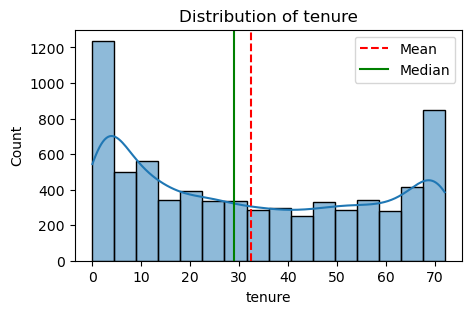

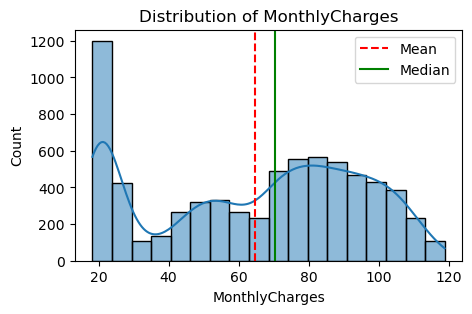

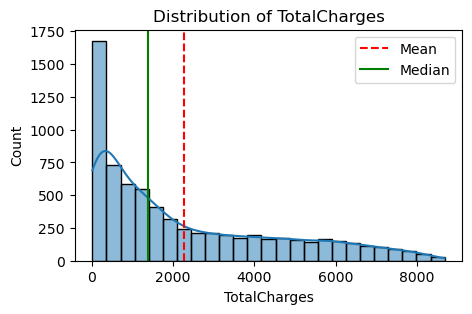

In [33]:
num_features = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in num_features:
    plt.figure(figsize=(5,3))
    sns.histplot(data[col], kde=True)
    plt.axvline(data[col].mean(), color="red", linestyle="--", label="Mean")
    plt.axvline(data[col].median(), color="green", linestyle="-", label="Median")
    plt.title(f"Distribution of {col}")
    plt.legend()
    plt.show()

## 5. Encode Categorical Variables
- Convert the target column `Churn` to 0 and 1 for prediction.  
- Encode all other categorical columns into numbers using `LabelEncoder`.  
- Save the encoders to process new data consistently in the future.

In [20]:
data['Churn'] = data['Churn'].replace({'Yes':1,'No':0}).astype(int)


C:\Users\LTC2023\AppData\Local\Temp\ipykernel_15812\2957799121.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Churn'] = data['Churn'].replace({'Yes':1,'No':0}).astype(int)


In [21]:
data_categorical = data.select_dtypes(include='object')


In [22]:
encoders = {}
for col in data_categorical:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    encoders[col] = le

In [10]:
encoders

{'customerID': LabelEncoder(),
 'gender': LabelEncoder(),
 'SeniorCitizen': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'tenure': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder(),
 'MonthlyCharges': LabelEncoder(),
 'TotalCharges': LabelEncoder(),
 'Churn': LabelEncoder()}

## 6. Split the Data
- Separate the dataset into features (`X`) and target (`y`).  
- Split into training (70%) and testing (30%) sets using `train_test_split` to evaluate the mode

In [23]:
X = data.drop(columns=['Churn'])
y = data['Churn']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## 7. Handle Class Imbalance with SMOTE
- Typically, the churn class (customers who leave) is underrepresented.  
- SMOTE generates synthetic samples for the minority class to balance the dataset and improve model performance.  
- Display counts before and after SMOTE to verify balancing.

In [26]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [27]:

print("Before SMOTE:\n", y_train.value_counts())
print("After SMOTE:\n", pd.Series(y_train_res).value_counts())

Before SMOTE:
 Churn
0    3635
1    1295
Name: count, dtype: int64
After SMOTE:
 Churn
0    3635
1    3635
Name: count, dtype: int64


## 8. Hyperparameter Tuning for XGBoost
- Define a grid of possible hyperparameters (`n_estimators`, `max_depth`, `learning_rate`, `subsample`).  
- Use `RandomizedSearchCV` to test different combinations and select the best one based on ROC-AUC score.  
- The best model is stored for final predictions.

In [28]:
param_grid = {
    'n_estimators': [100, 200, 300,400,500],
    'max_depth': [3,4,5,6,7],
    'learning_rate': [0.01, 0.05, 0.1,10],
    'subsample': [0.7,0.8,1.0]
}
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
search = RandomizedSearchCV(xgb, param_grid, n_iter=10, scoring='roc_auc', cv=5, random_state=42, n_jobs=-1)
search.fit(X_train_res, y_train_res)


C:\Users\LTC2023\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:12:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1, 10],
                                        'max_depth': [3, 4, 5, 6, 7],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='roc_auc')

In [29]:

best_model = search.best_estimator_
print("Best Parameters:", search.best_params_)

Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1}


## 9. Make Predictions
- Use the trained model to estimate the probability that each customer belongs to the churn class.  
- Apply a threshold (e.g., 0.3) to classify customers as churners or not.  
- The threshold can be adjusted to prioritize sensitivity or precision depending on business goal

In [30]:
from sklearn.metrics import precision_recall_curve, average_precision_score

y_prob = best_model.predict_proba(X_test)[:, 1]

In [31]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
average_precision = average_precision_score(y_test, y_prob)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]


In [32]:
y_pred_optimal = (y_prob > best_threshold).astype(int)


## 10. Model Evaluation
- Evaluate the model using multiple metrics:  
  - `Confusion Matrix`: counts of True Positives, False Positives, True Negatives, and False Negatives.  
  - `Classification Report`: Precision, Recall, F1-Score for each class.  
  - `Accuracy`: overall correct classification rate.  
  - `ROC-AUC`: threshold-independent measure of model performance.

In [33]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_optimal))
print("\nClassification Report:\n", classification_report(y_test, y_pred_optimal))
print("Accuracy:", accuracy_score(y_test, y_pred_optimal))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Confusion Matrix:
 [[1164  375]
 [ 142  432]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.76      0.82      1539
           1       0.54      0.75      0.63       574

    accuracy                           0.76      2113
   macro avg       0.71      0.75      0.72      2113
weighted avg       0.79      0.76      0.77      2113

Accuracy: 0.7553241836251775
ROC-AUC: 0.8269091880559574


### Confusion Matrix Interpretation

- **True Negatives (TN = 1153):**  
  Customers who did not churn and were correctly identified by the model.

- **False Positives (FP = 386):**  
  Customers predicted to churn but actually stayed.  
  This number decreased compared to previous thresholds, improving the model’s precision.

- **False Negatives (FN = 136):**  
  Customers who actually churned but were predicted as non-churners.  
  This number is relatively low, meaning the model successfully detected most churners.

- **True Positives (TP = 438):**  
  Customers who churned and were correctly identified by the model.

**Analysis:**  
- The model is now **balanced**: it detects most customers who will churn (**high recall**) while reducing false alarms (**improved precision**).  
- This balance is crucial for customer retention strategies:  
  the company can target predicted churners with retention campaigns without unnecessarily contacting too many non-churners.

## 11. Plot ROC Curve
- The ROC curve visualizes the trade-off between True Positive Rate and False Positive Rate.  
- A higher AUC value (closer to 1) indicates a better model performance.

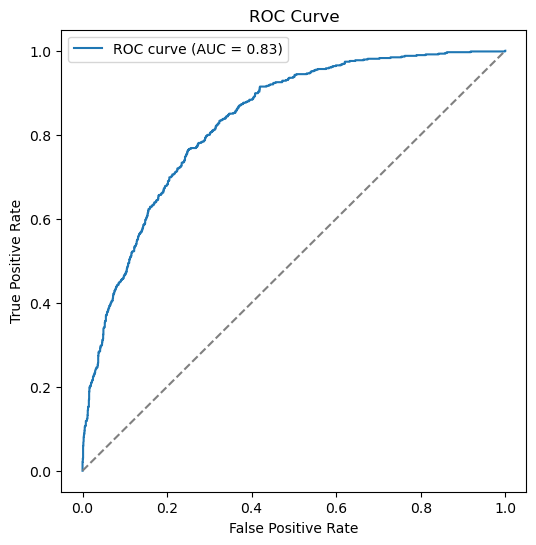

In [58]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## 12. Feature Importance
- Analyze which features have the most impact on predicting churn.  
- This helps prioritize strategies to retain customers or improve services related to these features.

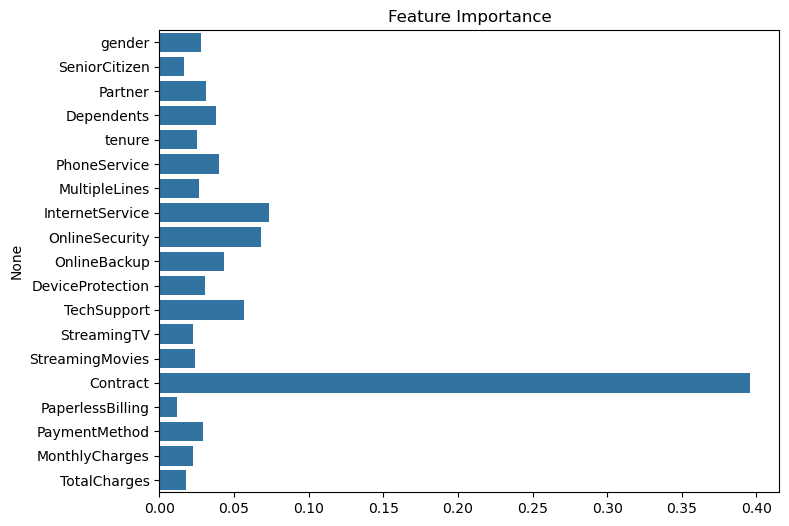

In [36]:
importances = best_model.feature_importances_
plt.figure(figsize=(8,6))
sns.barplot(x=importances, y=X.columns)
plt.title('Feature Importance')
plt.show()

## Conclusion
- The project covers all steps from data loading, cleaning, exploration, encoding, handling class imbalance, training an XGBoost model, hyperparameter tuning, evaluating performance, and visualizing results.  
- Thresholds and hyperparameters can be adjusted to optimize the model according to business goals.  